In [1]:
import pandas as pd

Analyse des intentions de votes pour l'année 2022

In [17]:
pres=pd.read_json("presidentielle.json")

In [18]:
pres

,id,nom_institut,debut_enquete,fin_enquete,rolling,media,commanditaire,lien,echantillon,population,tours
0,20220102_0105r_ow,Opinion Way,2022-01-02,2022-01-05,True,True,"Les Echos, Radio Classique, Kea Partners",http://www.commission-des-sondages.fr/notices/...,1501,Inscrits sur les listes électorales,"[{'tour': 'Premier tour', 'hypotheses': [{'hyp..."
1,20220225_0228_hi,Harris Interactive,2022-02-25,2022-02-28,False,True,Challenges,http://www.commission-des-sondages.fr/notices/...,2311,Inscrits sur les listes électorales,"[{'tour': 'Premier tour', 'hypotheses': [{'hyp..."
2,20211018_1020_ow,Opinion Way,2021-10-18,2021-10-20,False,True,"Les Echos, Radio Classique, CNews",http://www.commission-des-sondages.fr/notices/...,1035,Inscrits sur les listes électorales,"[{'tour': 'Premier tour', 'hypotheses': [{'hyp..."
3,20211005_1006_ifp,Ifop,2021-10-05,2021-10-06,False,True,"Fiducial, Sud Radio",http://www.commission-des-sondages.fr/notices/...,921,Inscrits sur les listes électorales,"[{'tour': 'Premier tour', 'hypotheses': [{'hyp..."
4,20220310_0314r_ips,Ipsos,2022-03-10,2022-03-14,True,True,"Le Parisien, France Info",http://www.commission-des-sondages.fr/notices/...,915,Certains d'aller voter,"[{'tour': 'Deuxième tour', 'hypotheses': [{'hy..."
...,...,...,...,...,...,...,...,...,...,...,...
404,20220410_0410_ow,Opinion Way,2022-04-10,2022-04-10,False,True,"CNews, Europe 1",https://www.opinion-way.com/fr/component/edocm...,1739,Inscrits sur les listes électorales,"[{'tour': 'Deuxième tour', 'hypotheses': [{'hy..."
405,20220421_0421_odx,Odoxa,2022-04-21,2022-04-21,False,True,"L'Obs, Mascaret",http://www.commission-des-sondages.fr/notices/...,1901,Inscrits sur les listes électorales,"[{'tour': 'Deuxième tour', 'hypotheses': [{'hy..."
406,20220410_0412r_ow,Opinion Way,2022-04-10,2022-04-12,True,True,"Les Echos, Radio Classique, Kea Partners",http://www.commission-des-sondages.fr/notices/...,1600,Inscrits sur les listes électorales,"[{'tour': 'Deuxième tour', 'hypotheses': [{'hy..."
407,20220413_0414_ow,Opinion Way,2022-04-13,2022-04-14,False,True,CNews,http://www.commission-des-sondages.fr/notices/...,1024,Inscrits sur les listes électorales,"[{'tour': 'Deuxième tour', 'hypotheses': [{'hy..."


In [19]:
pres=pres.explode('tours',ignore_index=True)

In [20]:
pres

,id,nom_institut,debut_enquete,fin_enquete,rolling,media,commanditaire,lien,echantillon,population,tours
0,20220102_0105r_ow,Opinion Way,2022-01-02,2022-01-05,True,True,"Les Echos, Radio Classique, Kea Partners",http://www.commission-des-sondages.fr/notices/...,1501,Inscrits sur les listes électorales,"{'tour': 'Premier tour', 'hypotheses': [{'hypo..."
1,20220102_0105r_ow,Opinion Way,2022-01-02,2022-01-05,True,True,"Les Echos, Radio Classique, Kea Partners",http://www.commission-des-sondages.fr/notices/...,1501,Inscrits sur les listes électorales,"{'tour': 'Deuxième tour', 'hypotheses': [{'hyp..."
2,20220225_0228_hi,Harris Interactive,2022-02-25,2022-02-28,False,True,Challenges,http://www.commission-des-sondages.fr/notices/...,2311,Inscrits sur les listes électorales,"{'tour': 'Premier tour', 'hypotheses': [{'hypo..."
3,20220225_0228_hi,Harris Interactive,2022-02-25,2022-02-28,False,True,Challenges,http://www.commission-des-sondages.fr/notices/...,2311,Inscrits sur les listes électorales,"{'tour': 'Deuxième tour', 'hypotheses': [{'hyp..."
4,20211018_1020_ow,Opinion Way,2021-10-18,2021-10-20,False,True,"Les Echos, Radio Classique, CNews",http://www.commission-des-sondages.fr/notices/...,1035,Inscrits sur les listes électorales,"{'tour': 'Premier tour', 'hypotheses': [{'hypo..."
...,...,...,...,...,...,...,...,...,...,...,...
702,20220410_0410_ow,Opinion Way,2022-04-10,2022-04-10,False,True,"CNews, Europe 1",https://www.opinion-way.com/fr/component/edocm...,1739,Inscrits sur les listes électorales,"{'tour': 'Deuxième tour', 'hypotheses': [{'hyp..."
703,20220421_0421_odx,Odoxa,2022-04-21,2022-04-21,False,True,"L'Obs, Mascaret",http://www.commission-des-sondages.fr/notices/...,1901,Inscrits sur les listes électorales,"{'tour': 'Deuxième tour', 'hypotheses': [{'hyp..."
704,20220410_0412r_ow,Opinion Way,2022-04-10,2022-04-12,True,True,"Les Echos, Radio Classique, Kea Partners",http://www.commission-des-sondages.fr/notices/...,1600,Inscrits sur les listes électorales,"{'tour': 'Deuxième tour', 'hypotheses': [{'hyp..."
705,20220413_0414_ow,Opinion Way,2022-04-13,2022-04-14,False,True,CNews,http://www.commission-des-sondages.fr/notices/...,1024,Inscrits sur les listes électorales,"{'tour': 'Deuxième tour', 'hypotheses': [{'hyp..."


In [21]:
pres_tour=[i['tour'] for i in pres['tours']]
pres_hyp=[i['hypotheses'] for i in pres['tours']]

In [22]:
pres['tour']=pres_tour
pres['hypo']=pres_hyp

In [23]:
pres=pres.explode('hypo',ignore_index=True)

In [24]:
pres.drop(columns=['debut_enquete','rolling','media','lien','id','tours'],inplace=True)

In [25]:
pres

,nom_institut,fin_enquete,commanditaire,echantillon,population,tour,hypo
0,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,"{'hypothese': None, 'sous_echantillon': 1245.8..."
1,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': 'Hypothèse Macron / Pécresse', '..."
2,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': 'Hypothèse Macron / Le Pen', 'so..."
3,Harris Interactive,2022-02-28,Challenges,2311,Inscrits sur les listes électorales,Premier tour,"{'hypothese': None, 'sous_echantillon': 1987.4..."
4,Harris Interactive,2022-02-28,Challenges,2311,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': 'Hypothèse Macron / Le Pen', 'so..."
...,...,...,...,...,...,...,...
1323,Opinion Way,2022-04-10,"CNews, Europe 1",1739,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': None, 'sous_echantillon': 1373.8..."
1324,Odoxa,2022-04-21,"L'Obs, Mascaret",1901,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': None, 'sous_echantillon': 1520.8..."
1325,Opinion Way,2022-04-12,"Les Echos, Radio Classique, Kea Partners",1600,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': None, 'sous_echantillon': 1264, ..."
1326,Opinion Way,2022-04-14,CNews,1024,Inscrits sur les listes électorales,Deuxième tour,"{'hypothese': None, 'sous_echantillon': 788.48..."


In [26]:
infos_expanded = pres['hypo'].apply(pd.Series)
new_pres = pd.concat([pres.drop(columns=['hypo']), infos_expanded], axis=1)

In [27]:
new_pres

,nom_institut,fin_enquete,commanditaire,echantillon,population,tour,hypothese,sous_echantillon,candidats
0,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,"[{'candidat': 'Marine Le Pen', 'parti': ['Rass..."
1,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Deuxième tour,Hypothèse Macron / Pécresse,900.60,"[{'candidat': 'Valérie Pécresse', 'parti': ['L..."
2,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Deuxième tour,Hypothèse Macron / Le Pen,1050.70,"[{'candidat': 'Emmanuel Macron', 'parti': ['LR..."
3,Harris Interactive,2022-02-28,Challenges,2311,Inscrits sur les listes électorales,Premier tour,None,1987.46,"[{'candidat': 'Jean Lassalle', 'parti': ['Rési..."
4,Harris Interactive,2022-02-28,Challenges,2311,Inscrits sur les listes électorales,Deuxième tour,Hypothèse Macron / Le Pen,1756.36,"[{'candidat': 'Marine Le Pen', 'parti': ['Rass..."
...,...,...,...,...,...,...,...,...,...
1323,Opinion Way,2022-04-10,"CNews, Europe 1",1739,Inscrits sur les listes électorales,Deuxième tour,None,1373.81,"[{'candidat': 'Marine Le Pen', 'parti': ['Rass..."
1324,Odoxa,2022-04-21,"L'Obs, Mascaret",1901,Inscrits sur les listes électorales,Deuxième tour,None,1520.80,"[{'candidat': 'Emmanuel Macron', 'parti': ['LR..."
1325,Opinion Way,2022-04-12,"Les Echos, Radio Classique, Kea Partners",1600,Inscrits sur les listes électorales,Deuxième tour,None,1264.00,"[{'candidat': 'Marine Le Pen', 'parti': ['Rass..."
1326,Opinion Way,2022-04-14,CNews,1024,Inscrits sur les listes électorales,Deuxième tour,None,788.48,"[{'candidat': 'Emmanuel Macron', 'parti': ['LR..."


In [28]:
new_pres=new_pres.explode('candidats',ignore_index=True)

In [29]:
new_pres

,nom_institut,fin_enquete,commanditaire,echantillon,population,tour,hypothese,sous_echantillon,candidats
0,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,"{'candidat': 'Marine Le Pen', 'parti': ['Rasse..."
1,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,"{'candidat': 'Anne Hidalgo', 'parti': ['Parti ..."
2,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,"{'candidat': 'Jean-Luc Mélenchon', 'parti': ['..."
3,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,"{'candidat': 'Nicolas Dupont-Aignan', 'parti':..."
4,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,"{'candidat': 'Arnaud Montebourg', 'parti': [''..."
...,...,...,...,...,...,...,...,...,...
8858,Opinion Way,2022-04-12,"Les Echos, Radio Classique, Kea Partners",1600,Inscrits sur les listes électorales,Deuxième tour,None,1264.00,"{'candidat': 'Emmanuel Macron', 'parti': ['LRM..."
8859,Opinion Way,2022-04-14,CNews,1024,Inscrits sur les listes électorales,Deuxième tour,None,788.48,"{'candidat': 'Emmanuel Macron', 'parti': ['LRM..."
8860,Opinion Way,2022-04-14,CNews,1024,Inscrits sur les listes électorales,Deuxième tour,None,788.48,"{'candidat': 'Marine Le Pen', 'parti': ['Rasse..."
8861,Harris Interactive,2022-04-11,Challenges,2172,Inscrits sur les listes électorales,Deuxième tour,None,1672.44,"{'candidat': 'Emmanuel Macron', 'parti': ['LRM..."


In [30]:
infos_expanded = new_pres['candidats'].apply(pd.Series)
new_pres = pd.concat([new_pres.drop(columns=['candidats']), infos_expanded], axis=1)

In [31]:
new_pres['parti'] = new_pres['parti'].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)

In [32]:
pres=new_pres

In [33]:
del infos_expanded, new_pres, pres_hyp, pres_tour

In [34]:
pres

,nom_institut,fin_enquete,commanditaire,echantillon,population,tour,hypothese,sous_echantillon,candidat,parti,intentions,erreur_sup,erreur_inf
0,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,Marine Le Pen,Rassemblement national,16.0,18.0358,13.9642
1,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,Anne Hidalgo,Parti socialiste,4.0,5.0882,2.9118
2,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,Jean-Luc Mélenchon,France insoumise,9.0,10.5892,7.4108
3,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,Nicolas Dupont-Aignan,Debout la France,2.0,2.7774,1.2226
4,Opinion Way,2022-01-05,"Les Echos, Radio Classique, Kea Partners",1501,Inscrits sur les listes électorales,Premier tour,None,1245.83,Arnaud Montebourg,,1.0,1.5525,0.4475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8858,Opinion Way,2022-04-12,"Les Echos, Radio Classique, Kea Partners",1600,Inscrits sur les listes électorales,Deuxième tour,None,1264.00,Emmanuel Macron,LRM,54.0,56.7476,51.2524
8859,Opinion Way,2022-04-14,CNews,1024,Inscrits sur les listes électorales,Deuxième tour,None,788.48,Emmanuel Macron,LRM,53.0,56.4838,49.5162
8860,Opinion Way,2022-04-14,CNews,1024,Inscrits sur les listes électorales,Deuxième tour,None,788.48,Marine Le Pen,Rassemblement national,47.0,50.4838,43.5162
8861,Harris Interactive,2022-04-11,Challenges,2172,Inscrits sur les listes électorales,Deuxième tour,None,1672.44,Emmanuel Macron,LRM,53.0,55.3920,50.6080


In [35]:
pres[(pres['tour']=='Premier tour') & (pres['hypothese'].notnull())]

,nom_institut,fin_enquete,commanditaire,echantillon,population,tour,hypothese,sous_echantillon,candidat,parti,intentions,erreur_sup,erreur_inf
39,Opinion Way,2021-10-20,"Les Echos, Radio Classique, CNews",1035,Inscrits sur les listes électorales,Premier tour,Hypothèse Pécresse / Zemmour,838.35,Anne Hidalgo,Parti socialiste,7.0,8.7272,5.2728
40,Opinion Way,2021-10-20,"Les Echos, Radio Classique, CNews",1035,Inscrits sur les listes électorales,Premier tour,Hypothèse Pécresse / Zemmour,838.35,Nicolas Dupont-Aignan,Debout la France,3.0,4.1548,1.8452
41,Opinion Way,2021-10-20,"Les Echos, Radio Classique, CNews",1035,Inscrits sur les listes électorales,Premier tour,Hypothèse Pécresse / Zemmour,838.35,Marine Le Pen,Rassemblement national,19.0,21.6556,16.3444
42,Opinion Way,2021-10-20,"Les Echos, Radio Classique, CNews",1035,Inscrits sur les listes électorales,Premier tour,Hypothèse Pécresse / Zemmour,838.35,Yannick Jadot,EE-LV,8.0,9.8365,6.1635
43,Opinion Way,2021-10-20,"Les Echos, Radio Classique, CNews",1035,Inscrits sur les listes électorales,Premier tour,Hypothèse Pécresse / Zemmour,838.35,Valérie Pécresse,Les Républicains,8.0,9.8365,6.1635
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7369,Ifop,2020-06-19,"CNews, Sud Radio",992,Inscrits sur les listes électorales,Premier tour,Hypothèse Xavier Bertrand,615.04,Philippe Poutou,NPA,0.5,1.0574,-0.0574
7370,Ifop,2020-06-19,"CNews, Sud Radio",992,Inscrits sur les listes électorales,Premier tour,Hypothèse Xavier Bertrand,615.04,Jean-Christophe Lagarde,UDI,0.5,1.0574,-0.0574
7371,Ifop,2020-06-19,"CNews, Sud Radio",992,Inscrits sur les listes électorales,Premier tour,Hypothèse Xavier Bertrand,615.04,François Asselineau,UPR,0.5,1.0574,-0.0574
7372,Ifop,2020-06-19,"CNews, Sud Radio",992,Inscrits sur les listes électorales,Premier tour,Hypothèse Xavier Bertrand,615.04,Yannick Jadot,EE-LV,8.0,10.1441,5.8559


intentions en %!!!

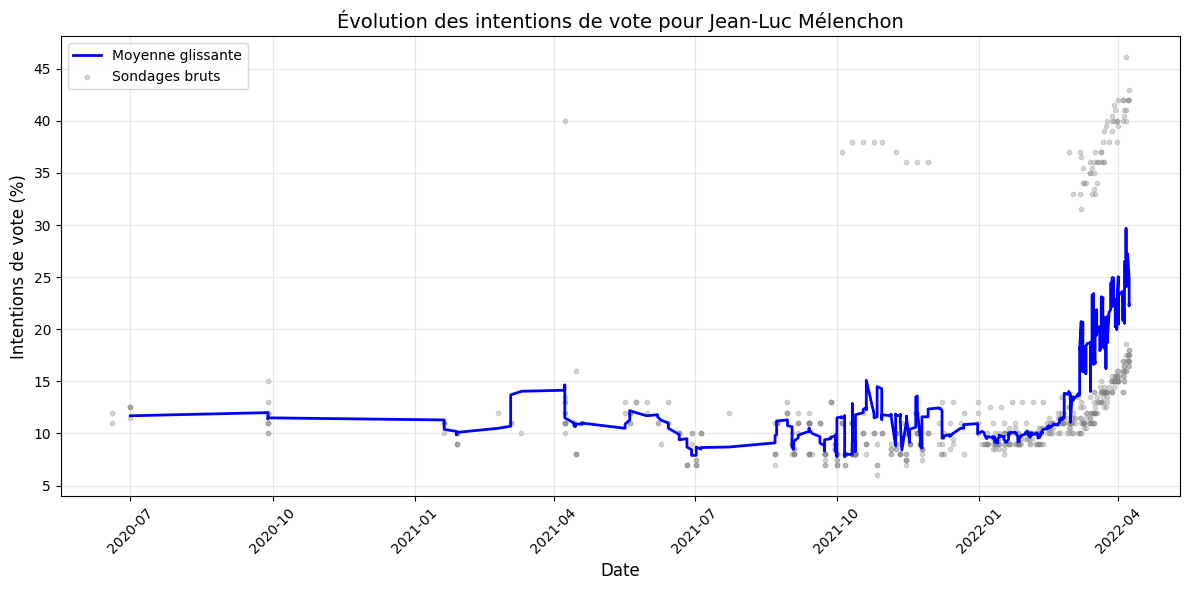

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Tri par date
df_melenchon = pres[pres['candidat'] == "Jean-Luc Mélenchon"].copy()
df_melenchon['fin_enquete'] = pd.to_datetime(df_melenchon['fin_enquete'])
df_melenchon = df_melenchon.sort_values('fin_enquete')

# Moyenne glissante sur 3 sondages
df_melenchon['rolling'] = df_melenchon['intentions'].rolling(window=10, center=True).mean()

# Taille de la figure et style
plt.figure(figsize=(12, 6))
plt.plot(df_melenchon['fin_enquete'], df_melenchon['rolling'], label="Moyenne glissante", linewidth=2, color='blue')
plt.scatter(df_melenchon['fin_enquete'], df_melenchon['intentions'], alpha=0.3, s=10, label="Sondages bruts", color='gray')

# Mise en forme
plt.title("Évolution des intentions de vote pour Jean-Luc Mélenchon", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Intentions de vote (%)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
pres.columns

Index(['nom_institut', 'fin_enquete', 'commanditaire', 'echantillon',
       'population', 'tour', 'hypothese', 'sous_echantillon', 'candidat',
       'parti', 'intentions', 'erreur_sup', 'erreur_inf'],
      dtype='object')

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ====== Chargement de ton DataFrame ======
# Remplace ceci si tu as déjà ton DataFrame chargé autrement
# df = pd.read_csv("chemin/vers/ton_fichier.csv")

# ====== Paramètre : le nom du candidat que tu veux analyser ======

def plot_candidat(candidat):
# ====== Nettoyage et préparation ======
    pres['fin_enquete'] = pd.to_datetime(pres['fin_enquete'])  # Conversion en datetime
    df_candidat = pres[pres['candidat'] == candidat].copy()

    # Création d’une colonne "mois" : au format AAAA-MM
    df_candidat['mois'] = df_candidat['fin_enquete'].dt.to_period('M').astype(str)

    # ====== Moyenne des intentions par mois ======
    moyennes_mensuelles = df_candidat.groupby('mois')['intentions'].mean()

    # ====== Affichage graphique ======
    plt.figure(figsize=(12, 6))
    plt.plot(moyennes_mensuelles.index, moyennes_mensuelles.values, marker='o')
    plt.title(f"Moyenne mensuelle des intentions de vote pour {candidat}")
    plt.xlabel("Mois")
    plt.ylabel("Intentions de vote (%)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


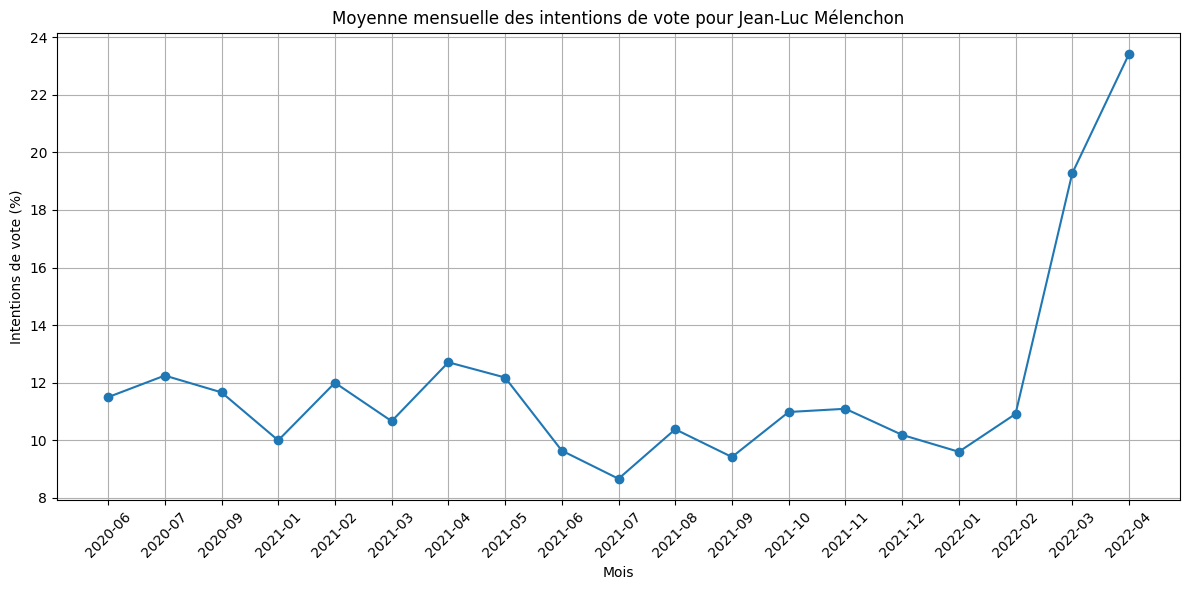

In [44]:
plot_candidat("Jean-Luc Mélenchon")

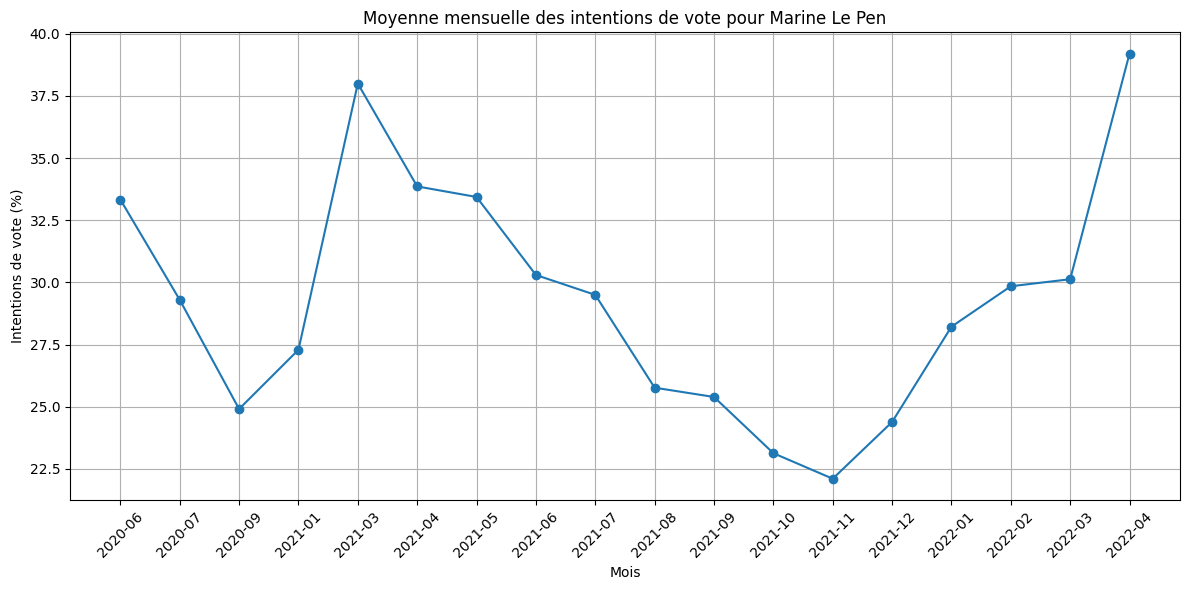

In [45]:
plot_candidat("Marine Le Pen")

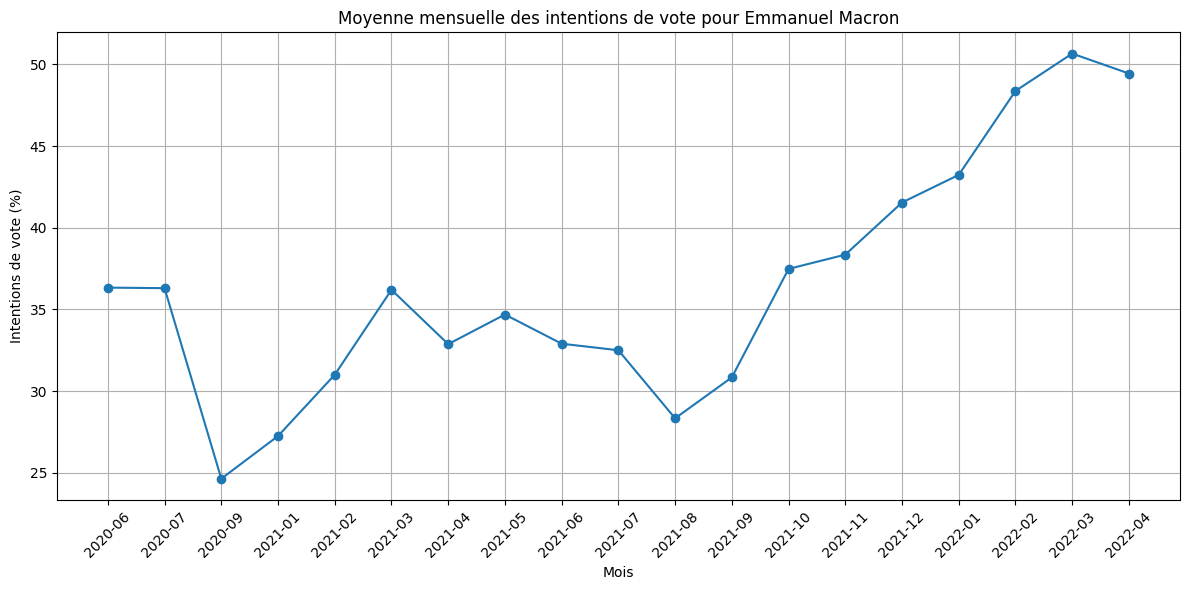

In [47]:
plot_candidat('Emmanuel Macron')

C:\Users\math\AppData\Local\Temp\ipykernel_4336\1505400111.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  moyennes = df_c.groupby('mois').apply(
C:\Users\math\AppData\Local\Temp\ipykernel_4336\1505400111.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  moyennes = df_c.groupby('mois').apply(
C:\Users\math\AppData\Local\Temp\ipykernel_4336\1505400111.py:27: DeprecationWarning: DataFrameGroupBy.apply

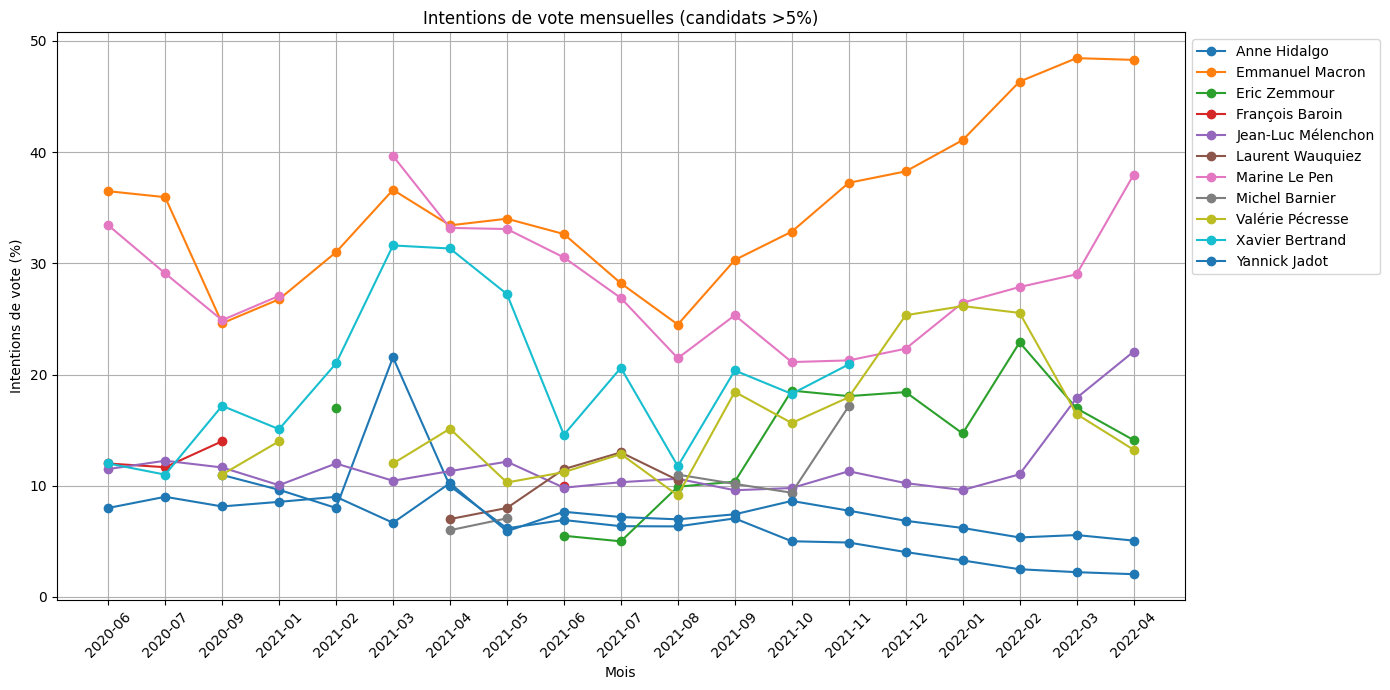

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Base temporelle complète (à adapter si besoin)
mois_complets = [
    '2020-06', '2020-07', '2020-09', '2021-01', '2021-02', '2021-03',
    '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09',
    '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03',
    '2022-04'
]

# Conversion de date
pres['fin_enquete'] = pd.to_datetime(pres['fin_enquete'])
pres['mois'] = pres['fin_enquete'].dt.to_period('M').astype(str)

# Filtrage des candidats significatifs (>5%)
candidats_significatifs = pres.groupby('candidat')['intentions'].max()
candidats_significatifs = candidats_significatifs[candidats_significatifs > 10].index

# Préparation du graphique
plt.figure(figsize=(14, 7))

for candidat in candidats_significatifs:
    df_c = pres[pres['candidat'] == candidat].copy()
    
    # Moyenne mensuelle pondérée
    moyennes = df_c.groupby('mois').apply(
        lambda x: (x['intentions'] * x['sous_echantillon']).sum() / x['sous_echantillon'].sum()
    )
    
    # Réindexage avec tous les mois, pour forcer les NaN (trous) où pas de données
    moyennes = moyennes.reindex(mois_complets)
    
    # Tracé : on n’interpole pas, on affiche les valeurs connues
    plt.plot(mois_complets, moyennes.values, marker='o', label=candidat)

# Mise en forme
plt.title("Intentions de vote mensuelles (candidats >5%)")
plt.xlabel("Mois")
plt.ylabel("Intentions de vote (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()
